In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from src.cleaning import clean
from src.feature_engineering import build_panel_data

df = pd.read_csv(config.DB_LOCATION)
cleaned, full_history = clean(df)
panel_data, last_complete_year = build_panel_data(cleaned, full_history)

train = panel_data[panel_data['Year'] < 2023]
calibrate = panel_data[panel_data['Year'] == 2023]
test = panel_data[panel_data['Year'] == 2024]

train_X = train[config.FEATURES]
train_y = train['Churns']
validate_X = calibrate[config.FEATURES]
validate_y = calibrate['Churns']
test_X = test[config.FEATURES]
test_y = test['Churns']

clf = HistGradientBoostingClassifier(
    random_state=42,
    learning_rate=config.FINAL_PARAMS['learning_rate'],
    max_depth=config.FINAL_PARAMS['max_depth'],
    max_iter=config.FINAL_PARAMS['max_iter'],
    l2_regularization=config.FINAL_PARAMS['l2_regularization']
)
clf.fit(train_X, train_y)
probs = clf.predict_proba(test_X)[:, 1]

C:\Users\bnpar\AppData\Local\Temp\ipykernel_26116\3153169030.py:12: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config.DB_LOCATION)


In [4]:
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
calibrated_clf = CalibratedClassifierCV(FrozenEstimator(clf), method='sigmoid')
calibrated_clf.fit(validate_X, validate_y)
probs = calibrated_clf.predict_proba(test_X)[:, 1]



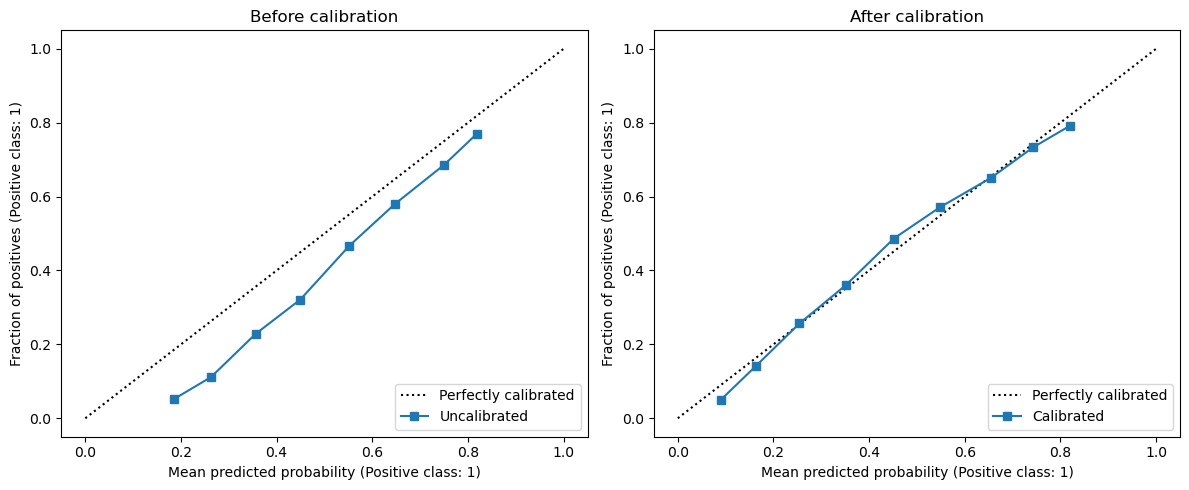

In [5]:
from sklearn.calibration import CalibrationDisplay

uncalibrated_probs = clf.predict_proba(test_X)[:, 1]
calibrated_probs = calibrated_clf.predict_proba(test_X)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

CalibrationDisplay.from_predictions(test_y, uncalibrated_probs, n_bins=10, ax=ax1, name='Uncalibrated')
ax1.set_title('Before calibration')

CalibrationDisplay.from_predictions(test_y, calibrated_probs, n_bins=10, ax=ax2, name='Calibrated')
ax2.set_title('After calibration')

plt.tight_layout()
plt.show()

The optimal threshold $p = t^*$ above which retention interventions should be applied can be determined by examining expected profit. 
The retention intervention takes the form of a half-price one-on-one coaching session if the lifter signs up for the next year's membership. The net cost of each coaching session to the federation is then
$$C = C_{\text{run session}} - \frac{1}{2} \text{Price}_{\text{session}}$$

and the expected revenue is then $$\text{revenue} =  P(\text{stay} \mid \text{intervention}) \cdot N_{p > t} \cdot (V - C) + \sum_{p_i < t} (1 - p_i)  \cdot V$$
where:
- $V$ is the value of a retained lifter, assumed equal across lifters
- $C$ is the net cost of the coaching session to the federation
- $t$ is the intervention threshold
- $N_{p > t}$ is the number of lifters with predicted churn probability above $t$
- $p_i$ is the predicted churn probability for lifter $i$
- $P(\text{stay} \mid \text{intervention})$ is the probability a lifter is retained given intervention, assumed constant across lifters and estimable via A/B test

$$t^* = \underset{t \in [0,1]}{\arg\max} \left[ P(\text{stay} \mid \text{intervention}) \cdot N_{p > t} \cdot (V - C) + \sum_{p_i < t} (1 - p_i) \cdot V \right]$$

The optimal threshold $t^*$ maximises expected profit. Since the relationship between $t$ and profit depends on the empirical distribution of predicted probabilities, this is found via searching over values of $t$ rather than analytically.


In [ ]:
V = 50
C = 10
p_retention = 0.33

thresholds = np.arange(0, 1.01, 0.01)
profits = []

for t in thresholds:
    intervene = probs > t
    n_intervene = intervene.sum()
    profit_intervened = p_retention * n_intervene * (V - C)
    profit_not_intervened = np.sum((1 - probs[~intervene]) * V)
    profits.append(profit_intervened + profit_not_intervened)
\
profits = np.array(profits)
t_star = thresholds[np.argmax(profits)]

In [ ]:
actual_revenue = np.sum(test_y == 0) * V
print(f'Actual 2024 revenue: £{actual_revenue:,.0f}')

In [ ]:
print(f'expected profit with interventions applied above t* = {t_star}: £{profits.max():,.0f}')
print(f'expected profit with no interventions: £{profits[thresholds == 1][0]:,.0f}')
print(f'expected profit uplift from interventions: £{profits.max() - profits[thresholds == 1.0][0]:,.0f}')




It can be seen that with $t^* = $SOMETHING, the expected increase in revenue due to retention interventions is £XXX, assuming $P(\text{stay} \mid \text{intervention})$ is PROBABILITY. 

The risk of applying interventions can be seen by looking at how the expected profit varies with $P(\text{stay} \mid \text{intervention})$. The value of $P(\text{stay} \mid \text{intervention})$ needed to breakeven on the retention interventions is calculated below.

In [ ]:
p_retentions = np.arange(0, 1.01, 0.01)

uplifts = []

intervene = probs > t_star
n_intervene = intervene.sum()
base_revenue = np.sum((1 - probs[~intervene]) * V)

for p in p_retentions:
    revenue = p * n_intervene * (V - C) + base_revenue
    uplifts.append(revenue - profits[-1])

breakeven = p_retentions[np.argmax(np.array(uplifts) >= 0)]
print(f'breakeven : {breakeven:.2f}')


In order for the retention interventions to not be expected to generate loss with interventions applied above $t^*$, the uptake of targeted lifters needs to be at least 28%.